# **Cell 1**

In [1]:
!pip install -U ultralytics opencv-python-headless torch torchvision --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.0/

# **Cell 2**

In [2]:
!pip install -U realesrgan --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.4/299.4 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 14.0 MB/s eta 0:00:00


# **Cell 3**

In [3]:
import os
import sys
import types
import urllib.request
import torch
import cv2
import numpy as np
from PIL import Image
from ultralytics import YOLO
from torchvision.transforms import functional as F

fake_ft = types.ModuleType("torchvision.transforms.functional_tensor")
fake_ft.rgb_to_grayscale = F.rgb_to_grayscale
sys.modules["torchvision.transforms.functional_tensor"] = fake_ft
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)
weights_url = "https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth"
weights_path = "RealESRGAN_x4plus.pth"

if not os.path.exists(weights_path):
    print("Téléchargement de RealESRGAN_x4plus.pth ...")
    urllib.request.urlretrieve(weights_url, weights_path)
    print("OK")

rrdbnet = RRDBNet(
    num_in_ch=3,
    num_out_ch=3,
    num_feat=64,
    num_block=23,
    num_grow_ch=32,
    scale=4,
)


upsampler = RealESRGANer(
    scale=4,
    model_path=weights_path,
    model=rrdbnet,
    tile=0,
    tile_pad=10,
    pre_pad=0,
    half=(device.type == "cuda"),
)

def enhance_image(img_pil: Image.Image) -> Image.Image:
    """
    Retourne une image PIL RGB.
    """
    img_bgr = cv2.cvtColor(np.array(img_pil.convert("RGB")), cv2.COLOR_RGB2BGR)
    output, _ = upsampler.enhance(img_bgr, outscale=1.0)  # outscale=1 => x4 interne mais même cadrage
    out_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
    return Image.fromarray(out_rgb)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device utilisé : cuda
Téléchargement de RealESRGAN_x4plus.pth ...
OK


# **Cell 4**

In [4]:
import torch
import cv2
import numpy as np
from PIL import Image
from ultralytics import YOLO
from google.colab import files

# **Cell 5**

In [5]:
print("➡️ Upload du modèle YOLOv8 pour la détection des véhicules")
veh_upload = files.upload()
vehicle_model_path = list(veh_upload.keys())[0]

➡️ Upload du modèle YOLOv8 pour la détection des véhicules


Saving best_Vehicules.pt to best_Vehicules.pt


# **Cell 6**

In [6]:
print("➡️ Upload du modèle YOLOv8 pour la détection des plaques")
plate_upload = files.upload()
plate_model_path = list(plate_upload.keys())[0]

➡️ Upload du modèle YOLOv8 pour la détection des plaques


Saving best_plaques_final.pt to best_plaques_final.pt


# **Cell 7**

In [7]:
vehicle_model = YOLO(vehicle_model_path)
plate_model = YOLO(plate_model_path)

device = "cuda" if torch.cuda.is_available() else "cpu"

# **Cell 8**

In [8]:
!pip install "transformers==4.36.2" "huggingface_hub==0.26.2"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.5/447.5 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 100.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 0.36.0
    Uninstalling huggingface-hub-0.36.0:
      Successfully uninstalled huggingface-hub-0.36.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.2
    Uninstalling transformers-4.57.2:
      Successfully uninstalled transformers-4.57.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the

# **Cell 9**

In [9]:
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# Reutilise 'device' défini plus haut
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
ocr_model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed").to(device)

def read_plate(img_pil: Image.Image) -> str:
    """
    Lit le texte d'une plaque avec TrOCR.
    L'image doit être en RGB.
    """
    if img_pil.mode != "RGB":
        img_pil = img_pil.convert("RGB")
    pixel_values = processor(images=img_pil, return_tensors="pt").pixel_values.to(device)
    generated_ids = ocr_model.generate(pixel_values, max_length=16)
    text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return text.replace(" ", "")

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `for

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-printed and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

# **Cell 10**

In [37]:
import re

def normalize_tunisian_plate(text: str) -> str:
    """
    Formate une plaque tunisienne sous la forme :
        XXX تونس YYYY

    - XXX : au plus 3 chiffres (à gauche)
    - YYYY : au plus 4 chiffres (à droite)

    Gère aussi le cas où l'OCR renvoie un seul bloc de chiffres
    (ex: '244396276' -> '244 تونس 6276').
    """
    text = text.strip()
    nums = re.findall(r"\d+", text)

    if not nums:
        return text

    if len(nums) >= 2:
        left  = nums[0][-3:]     # maximum 3 à gauche
        right = nums[-1][-4:]    # maximum 4 à droite
        return f"{left} تونس {right}"

    n = nums[0]
    if len(n) >= 6:
        raw_left  = n[:-4]
        raw_right = n[-4:]

        left  = raw_left[-3:]
        right = raw_right
        return f"{left} تونس {right}"

    return text


# Pour forcer l'affichage correct LTR/RTL
LRE = "\u202A"   # Left-to-Right Embedding
RLE = "\u202B"   # Right-to-Left Embedding
PDF = "\u202C"   # Pop directional formatting

def display_plate_pretty(text: str) -> str:
    """
    Affiche joliment une plaque déjà normalisée du type '245 تونس 5911'
    en forçant le sens LTR/RTL.
    """
    nums = re.findall(r"\d+", text)
    if len(nums) >= 2:
        left  = nums[0]
        right = nums[1]
        return f"{LRE}{left}{PDF} {RLE}تونس{PDF} {LRE}{right}{PDF}"
    return text


def detect_and_recognize(image_path: str):
    """
    Pipeline complet :
    1. Détection véhicule (YOLOv8) sur l'image originale
    2. Crop véhicule
    3. Détection plaque dans le crop véhicule
    4. GAN (Real-ESRGAN) uniquement sur le crop de la plaque
    5. Prétraitement doux (gris + equalize + retour RGB)
    6. OCR TrOCR
    7. Normalisation format tunisien
    """
    img = Image.open(image_path).convert("RGB")
    img_cv2 = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

    # 1) Détection véhicules
    veh_results = vehicle_model(img_cv2)[0]
    veh_boxes = veh_results.boxes.xyxy.cpu().numpy()

    if veh_boxes.shape[0] == 0:
        return None, "Aucun véhicule détecté"

    for (x1, y1, x2, y2) in veh_boxes[:, :4]:
        # 2) Crop véhicule
        veh_crop = img.crop((x1, y1, x2, y2))

        # 3) Détection plaque sur le véhicule
        veh_crop_cv2 = cv2.cvtColor(np.array(veh_crop), cv2.COLOR_RGB2BGR)
        plate_results = plate_model(veh_crop_cv2)[0]
        plate_boxes = plate_results.boxes.xyxy.cpu().numpy()

        if plate_boxes.shape[0] == 0:
            continue

        for (px1, py1, px2, py2) in plate_boxes[:, :4]:
            # 4) Crop plaque + GAN Real-ESRGAN
            plate_crop_raw = veh_crop.crop((px1, py1, px2, py2))
            plate_enh = enhance_image(plate_crop_raw)

            # 5) Prétraitement POUR OCR
            w, h = plate_enh.size
            target_h = 64
            scale = target_h / h
            target_w = int(w * scale)
            plate_final = plate_enh.resize((target_w, target_h), Image.BICUBIC).convert("RGB")


            # 6) OCR
            raw_text = read_plate(plate_final)

            # 7) Normalisation
            final_text = normalize_tunisian_plate(raw_text)

            return plate_final, final_text

    return None, "Aucune plaque détectée"

def detect_and_recognize_all_vehicles(image_path: str):
    """
    Pour une image :
      - détecte tous les véhicules
      - pour chaque véhicule, essaie de détecter une plaque
      - si plaque détectée : OCR + normalisation
      - sinon : "Plaque non détectée"

    Retourne une liste de dictionnaires :
      [
        {
          "vehicle_id": 1,
          "vehicle_crop": <PIL.Image>,
          "plate_crop_raw": <PIL.Image> ou None,
          "plate_crop_gan": <PIL.Image> ou None,
          "plate_crop_ocr": <PIL.Image> ou None,
          "plate_crop": <PIL.Image> ou None,   # alias de plate_crop_ocr
          "text_raw": str ou None,
          "text_normalized": str ou None,
          "status": "Plaque détectée" / "Plaque non détectée"
        },
        ...
      ]
    """

    img = Image.open(image_path).convert("RGB")
    img_cv2 = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    results = []
    veh_results = vehicle_model(img_cv2)[0]
    veh_boxes = veh_results.boxes.xyxy.cpu().numpy()

    if veh_boxes.shape[0] == 0:
        return []
    for idx, (x1, y1, x2, y2) in enumerate(veh_boxes[:, :4], start=1):
        veh_crop = img.crop((x1, y1, x2, y2))
        veh_crop_cv2 = cv2.cvtColor(np.array(veh_crop), cv2.COLOR_RGB2BGR)
        plate_results = plate_model(veh_crop_cv2)[0]
        plate_boxes = plate_results.boxes.xyxy.cpu().numpy()

        if plate_boxes.shape[0] == 0:
            results.append({
                "vehicle_id": idx,
                "vehicle_crop": veh_crop,
                "plate_crop_raw": None,
                "plate_crop_gan": None,
                "plate_crop_ocr": None,
                "plate_crop": None,
                "text_raw": None,
                "text_normalized": None,
                "status": "Plaque non détectée",
            })
            continue
        px1, py1, px2, py2 = plate_boxes[0, :4]
        plate_crop_raw = veh_crop.crop((px1, py1, px2, py2))
        plate_enh = enhance_image(plate_crop_raw)
        w, h = plate_enh.size
        target_h = 64
        scale = target_h / h
        target_w = int(w * scale)
        plate_final = plate_enh.resize((target_w, target_h), Image.BICUBIC).convert("RGB")
        raw_text = read_plate(plate_final)
        final_text = normalize_tunisian_plate(raw_text)

        results.append({
            "vehicle_id": idx,
            "vehicle_crop": veh_crop,
            "plate_crop_raw": plate_crop_raw,
            "plate_crop_gan": plate_enh,
            "plate_crop_ocr": plate_final,
            "plate_crop": plate_final,  # alias pour compatibilité
            "text_raw": raw_text,
            "text_normalized": final_text,
            "status": "Plaque détectée",
        })

    return results


<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-2654279306.py:12: SyntaxWarning: invalid escape sequence '\d'
  numbers = re.findall(r"\d+", text)


# **Cell 11**

In [11]:
from IPython.display import display

def debug_detect_and_recognize(image_path: str):
    """
    Version DEBUG du pipeline :
    - affiche le crop véhicule
    - affiche le crop plaque brut
    - affiche le crop plaque après GAN
    - affiche le crop plaque après prétraitement OCR
    - affiche le texte reconnu
    """
    img = Image.open(image_path).convert("RGB")
    img_cv2 = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

    print("🔹 Image originale")
    display(img)
    veh_results = vehicle_model(img_cv2)[0]
    veh_boxes = veh_results.boxes.xyxy.cpu().numpy()

    if veh_boxes.shape[0] == 0:
        print("❌ Aucun véhicule détecté")
        return None, "Aucun véhicule détecté"
    x1, y1, x2, y2 = veh_boxes[0, :4]
    veh_crop = img.crop((x1, y1, x2, y2))
    print("🚗 Crop véhicule")
    display(veh_crop)
    veh_crop_cv2 = cv2.cvtColor(np.array(veh_crop), cv2.COLOR_RGB2BGR)
    plate_results = plate_model(veh_crop_cv2)[0]
    plate_boxes = plate_results.boxes.xyxy.cpu().numpy()

    if plate_boxes.shape[0] == 0:
        print("❌ Aucune plaque détectée dans ce véhicule")
        return None, "Aucune plaque détectée"


    px1, py1, px2, py2 = plate_boxes[0, :4]
    plate_crop_raw = veh_crop.crop((px1, py1, px2, py2))
    print("🔳 Crop plaque brut (sans GAN)")
    display(plate_crop_raw)
    plate_enh = enhance_image(plate_crop_raw)
    print("🟦 Plaque après GAN (super-résolution)")
    display(plate_enh)
    w, h = plate_enh.size
    target_h = 64
    scale = target_h / h
    target_w = int(w * scale)
    plate_final = plate_enh.resize((target_w, target_h), Image.BICUBIC).convert("RGB")
    print("⚪ Plaque après prétraitement pour OCR")
    display(plate_final)
    raw_text = read_plate(plate_final)
    final_text = normalize_tunisian_plate(raw_text)

    print("📖 Texte brut OCR :", raw_text)
    print("✅ Texte normalisé :", format_plate_for_display(final_text))


    return plate_final, final_text

# **Cell 12**

Saving Première-édition-Paradis-Porsche-911-par-Tunisian-CARS-41.jpg to Première-édition-Paradis-Porsche-911-par-Tunisian-CARS-41.jpg

0: 288x640 2 cars, 63.6ms
Speed: 15.6ms preprocess, 63.6ms inference, 21.2ms postprocess per image at shape (1, 3, 288, 640)

0: 448x640 1 car-license-plate, 47.9ms
Speed: 1.6ms preprocess, 47.9ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)

0: 448x640 1 car-license-plate, 12.8ms
Speed: 4.0ms preprocess, 12.8ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)

🚗 Véhicule #1 — Plaque détectée
  → Crop véhicule :


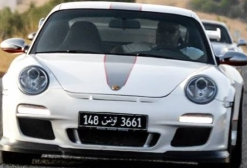

  → Crop plaque brut :


  → Crop plaque après GAN :


  → Crop plaque pour OCR :


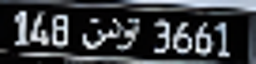

  → Texte brut OCR      : 148.593661
  → Texte normalisé OCR : ‪148‬ ‫تونس‬ ‪3661‬

🚗 Véhicule #2 — Plaque détectée
  → Crop véhicule :


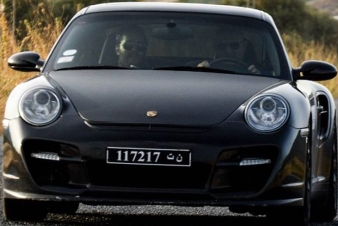

  → Crop plaque brut :


  → Crop plaque après GAN :


  → Crop plaque pour OCR :


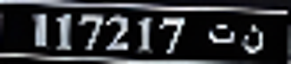

  → Texte brut OCR      : 117217@
  → Texte normalisé OCR : 117217@


In [12]:
from google.colab import files
from IPython.display import display
import re

LRE = "\u202A"
RLE = "\u202B"
PDF = "\u202C"

def format_plate_for_display(text: str) -> str:
    nums = re.findall(r"\d+", text)
    if len(nums) >= 2:
        left = nums[0][-3:]
        right = nums[-1][-4:]
        return f"{LRE}{left}{PDF} {RLE}تونس{PDF} {LRE}{right}{PDF}"
    return text

uploaded = files.upload()
if uploaded:
    img_path = list(uploaded.keys())[0]

    all_results = detect_and_recognize_all_vehicles(img_path)

    if not all_results:
        print("Aucun véhicule détecté.")
    else:
        for res in all_results:
            vid = res["vehicle_id"]
            print(f"\n🚗 Véhicule #{vid} — {res['status']}")

            print("  → Crop véhicule :")
            display(res["vehicle_crop"])

            if res["plate_crop"] is not None:
                print("  → Crop plaque brut :")
                display(res["plate_crop_raw"])
                print("  → Crop plaque après GAN :")
                display(res["plate_crop_gan"])
                print("  → Crop plaque pour OCR :")
                display(res["plate_crop_ocr"])
                print("  → Texte brut OCR      :", res["text_raw"])
                print("  → Texte normalisé OCR :", format_plate_for_display(res["text_normalized"] or ""))
            else:
                print("  → Aucune plaque à afficher.")



In [53]:
%%writefile app.py
import streamlit as st
import numpy as np
import cv2
import torch
from PIL import Image
import re

import sys, types
from torchvision.transforms import functional as F
fake_ft = types.ModuleType("torchvision.transforms.functional_tensor")
fake_ft.rgb_to_grayscale = F.rgb_to_grayscale
sys.modules["torchvision.transforms.functional_tensor"] = fake_ft
from ultralytics import YOLO
from realesrgan import RealESRGANer
from basicsr.archs.rrdbnet_arch import RRDBNet

from transformers import TrOCRProcessor, VisionEncoderDecoderModel

device = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# YOLO
# -----------------------------
vehicle_model = YOLO("best_Vehicules.pt")
plate_model   = YOLO("best_plaques_final.pt")

# -----------------------------
# OCR
# -----------------------------
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
ocr_model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed").to(device)

# -----------------------------
# ESRGAN
# -----------------------------
rrdbnet = RRDBNet(
    num_in_ch=3, num_out_ch=3,
    num_feat=64, num_block=23,
    num_grow_ch=32, scale=4
)
upsampler = RealESRGANer(
    scale=4,
    model_path="RealESRGAN_x4plus.pth",
    model=rrdbnet,
    tile=0, tile_pad=10, pre_pad=0,
    half=(device == "cuda")
)

# ===========================
# 2) Pipeline
# ===========================

def enhance_image(img_pil):
    img_bgr = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    output, _ = upsampler.enhance(img_bgr, outscale=1)
    return Image.fromarray(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))


def read_plate(img_pil):
    if img_pil.mode != "RGB":
        img_pil = img_pil.convert("RGB")
    pix = processor(images=img_pil, return_tensors="pt").pixel_values.to(device)
    ids = ocr_model.generate(pix, max_length=16)
    return processor.batch_decode(ids, skip_special_tokens=True)[0].replace(" ", "")


def detect_and_recognize_all(img_pil):
    img_cv2 = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    results = []
    veh_pred = vehicle_model(img_cv2)[0]
    veh_boxes = veh_pred.boxes.xyxy.cpu().numpy()
    veh_classes = veh_pred.boxes.cls.cpu().numpy().astype(int)

    if len(veh_boxes) == 0:
        return []

    for idx, (box, cls_id) in enumerate(zip(veh_boxes, veh_classes), 1):
        x1, y1, x2, y2 = box

        # Nom de la classe (car, truck, bus, ...)
        veh_label = vehicle_model.names.get(cls_id, f"class_{cls_id}")
        crop = img_pil.crop((x1, y1, x2, y2))
        cv2crop = cv2.cvtColor(np.array(crop), cv2.COLOR_RGB2BGR)
        plate_pred = plate_model(cv2crop)[0]
        plates = plate_pred.boxes.xyxy.cpu().numpy()

        if len(plates) == 0:
            results.append({
                "vehicle_id": idx,
                "vehicle_label": veh_label,
                "vehicle_crop": crop,
                "status": "Plaque non détectée",
                "plate_raw": None
            })
            continue

        px1, py1, px2, py2 = plates[0]
        plate_raw = crop.crop((px1, py1, px2, py2))
        plate_gan = enhance_image(plate_raw)

        w, h = plate_gan.size
        plate_ocr = plate_gan.resize((int(w * (64 / h)), 64), Image.BICUBIC)

        raw = read_plate(plate_ocr)
        norm = normalize_tunisian_plate(raw)

        results.append({
            "vehicle_id": idx,
            "vehicle_label": veh_label,
            "vehicle_crop": crop,
            "plate_raw": plate_raw,
            "plate_gan": plate_gan,
            "plate_ocr": plate_ocr,
            "text_raw": raw,
            "text_norm": norm,
            "status": "Plaque détectée"
        })

    return results


import re

def normalize_tunisian_plate(text: str) -> str:
    """
    Formate une plaque tunisienne sous la forme :
        XXX تونس YYYY

    - XXX : au plus 3 chiffres (à gauche)
    - YYYY : au plus 4 chiffres (à droite)

    """
    text = text.strip()
    nums = re.findall(r"\d+", text)

    if not nums:
        return text

    if len(nums) >= 2:
        left = nums[0][-3:]      # maximum 3 à gauche
        right = nums[-1][-4:]    # maximum 4 à droite
        return f"{left} تونس {right}"

    n = nums[0]
    if len(n) >= 6:
        raw_left = n[:-4]
        raw_right = n[-4:]
        left = raw_left[-3:]
        right = raw_right
        return f"{left} تونس {right}"

    return text


# Pour forcer l'affichage correct LTR/RTL
LRE = "\u202A"   # Left-to-Right Embedding
RLE = "\u202B"   # Right-to-Left Embedding
PDF = "\u202C"   # Pop directional formatting


def display_plate_pretty(text: str) -> str:
    """
    Affiche joliment une plaque déjà normalisée du type '245 تونس 5911'
    en forçant le sens LTR/RTL.
    """
    nums = re.findall(r"\d+", text)
    if len(nums) >= 2:
        left = nums[0]
        right = nums[1]
        return f"{LRE}{left}{PDF} {RLE}تونس{PDF} {LRE}{right}{PDF}"
    return text


# ===========================
# 3) Streamlit UI
# ===========================

st.title("🚍🚘 Automatic Number Plate Recognition System 🚐🚛")
st.markdown(
    "<h4 style='color:#555;'>🌶️ With the Tunisian Touch 🌶️ </h4>",
    unsafe_allow_html=True,
)

# --------- SIDEBAR ---------
with st.sidebar:
    st.header("⚙️ Options")

    source = st.radio(
        "Source de l'image :",
        ["📤 Uploader une image", "🧪 Image test 1", "🧪 Image test 2"],
    )

    st.markdown("---")
    st.subheader("ℹ️ Modèles utilisés")
    st.markdown(
        """
        - **Vehicule Detection** : YOLOv8 fine tuné
        - **Plate Detection** : YOLOv8 fine tuné
        - **Image enhancement** : Real-ESRGAN x4
        - **OCR** : Microsoft TrOCR
        """
    )

# --------- CHOIX DE L'IMAGE ---------
image = None

if source == "📤 Uploader une image":
    uploaded = st.file_uploader("📤 Importer une image", type=["jpg", "jpeg", "png"])
    if uploaded is not None:
        image = Image.open(uploaded).convert("RGB")
else:

    test_file_1 = "test7.jpg"
    test_file_2 = "test11.jpg"

    try:
        if source == "🧪 Image test 1":
            image = Image.open(test_file_1).convert("RGB")
        elif source == "🧪 Image test 2":
            image = Image.open(test_file_2).convert("RGB")
    except FileNotFoundError:
        st.error("⚠️ Les images de test ne sont pas trouvées. Vérifie les noms de fichiers dans app.py.")

# --------- AFFICHAGE + PIPELINE ---------
if image is not None:
    st.subheader("🖼️ Image originale")
    st.image(image, use_column_width=True)

    res = detect_and_recognize_all(image)

    if not res:
        st.error("❌ Aucun véhicule détecté.")
    else:
        st.subheader("📊 Résultats par véhicule détecté")

        for r in res:
            veh_label = r.get("vehicle_label", "vehicle")
            st.markdown(
                f"""
                <div style="margin-top: 10px; margin-bottom: 5px;">
                    <span style="font-size:1.1rem;">Véhicule #{r['vehicle_id']} — </span>
                    <span style="font-size:1.8rem; font-weight:800;">
                        {veh_label.upper()}
                    </span>
                    <span style="font-size:1.1rem;"> — {r['status']}</span>
                </div>
                """,
                unsafe_allow_html=True,
            )

            col1, col2 = st.columns([1, 1])

            with col1:
                st.caption("Crop véhicule")
                st.image(r["vehicle_crop"], use_column_width=True)

            if r.get("plate_raw") is not None:
                with col2:
                    st.caption("🔳 Plaque brute")
                    st.image(r["plate_raw"], use_column_width=True)

                col3, col4 = st.columns([1, 1])
                with col3:
                    st.caption("🟦 Plaque après GAN")
                    st.image(r["plate_gan"], use_column_width=True)
                with col4:
                    st.caption("⚪ Plaque utilisée pour OCR")
                    st.image(r["plate_ocr"], use_column_width=True)

                st.markdown(
                    f"**Texte brut OCR :** `{r['text_raw']}`  \n"
                    f"**Texte normalisé :** {display_plate_pretty(r['text_norm'])}"
                )
            else:
                st.warning("Aucune plaque détectée pour ce véhicule.")
else:
    st.info("➡️ Choisis une source dans la barre latérale (upload ou image test) pour commencer.")

# --------- FOOTER ---------
st.markdown(
    """
    <hr>
    <div style="text-align:center; color:#888; font-size:0.9rem; margin-top:10px;">
        Réalisé par: Salsabil Ben Halima — Étudiante en terminale Ingénierie des données
        Faculté des Sciences — Université de Sfax —
        Département d'Informatique et des Communications
    </div>
    """,
    unsafe_allow_html=True,
)


Overwriting app.py


# **Cell 13**

In [13]:
!pip install streamlit pyngrok --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 94.3 MB/s eta 0:00:00


# **Cell 14**

In [26]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

# **Cell 15**

In [54]:
!streamlit run app.py --server.headless true --server.port 8501 > streamlit_log.txt 2>&1 &

In [ ]:
!./cloudflared tunnel --url http://localhost:8501 --no-autoupdate

2025-12-06T04:44:13Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2025-12-06T04:44:13Z INF Requesting new quick Tunnel on trycloudflare.com...
2025-12-06T04:44:17Z INF +--------------------------------------------------------------------------------------------+
2025-12-06T04:44:17Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2025-12-06T04:44:17Z INF |  https://brothers-geography-chrome-bomb.trycloudflare.